### _Events_

- Event Data
- Event Display 
- etc

In [1]:
import sys, os, glob, yaml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import pprint
import networkx as nx
import seaborn as sns
import trackml.dataset

In [4]:
import torch
from torch_geometric.data import Data
import itertools

### _Dataset_

In [5]:
# mu+mu- data (current)
input_dir = 'train_all'

In [6]:
# Find All Input Data Files (hits.csv, cells.csv, particles.csv, truth.csv)
all_files = os.listdir(input_dir)

# Extract File Prefixes (use e.g. xxx-hits.csv)
suffix = '-hits.csv'
file_prefixes = sorted(os.path.join(input_dir, f.replace(suffix, ''))
                       for f in all_files if f.endswith(suffix))

print("Total Events: ", len(file_prefixes))

Total Events:  100000


In [7]:
file_prefixes[:10]

['train_all/event0000000000',
 'train_all/event0000000001',
 'train_all/event0000000002',
 'train_all/event0000000003',
 'train_all/event0000000004',
 'train_all/event0000000005',
 'train_all/event0000000006',
 'train_all/event0000000007',
 'train_all/event0000000008',
 'train_all/event0000000009']

In [8]:
# test to load an event
event_prefix = file_prefixes[10]

hits, tubes, particles, truth = trackml.dataset.load_event(event_prefix)

# memory usage
mem_bytes = (hits.memory_usage(index=True).sum() 
             + tubes.memory_usage(index=True).sum() 
             + particles.memory_usage(index=True).sum() 
             + truth.memory_usage(index=True).sum())

print('{} memory usage {:.2f} MB'.format(os.path.basename(event_prefix), mem_bytes / 2**20))

event0000000010 memory usage 0.03 MB


In [9]:
hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id
0,1,-16.618999,-1.515,35.0,9,0,28
1,2,-17.493700,-2.020,35.0,9,1,134
2,3,-18.368401,-1.515,35.0,9,2,245
3,4,-19.243099,-2.020,35.0,9,3,363
4,5,-20.117800,-1.515,35.0,9,4,486


In [10]:
tubes.head()

,hit_id,isochrone,depcharge,energyloss,volume_id,layer_id,module_id,skewed,sector_id
0,1,0.264577,6991560.0,6.99156,9,0,28,0,1
1,2,0.212534,9636670.0,9.63667,9,1,134,0,1
2,3,0.324681,2672830.0,2.67283,9,2,245,0,1
3,4,0.124096,4783760.0,4.78376,9,3,363,0,1
4,5,0.429915,3809810.0,3.80981,9,4,486,0,1


In [11]:
particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time
0,1,0.0,0.0,0.0,-0.126424,0.416378,0.290634,1,27,13,0
1,2,0.0,0.0,0.0,-0.284792,-0.202967,0.571600,1,25,13,0
2,3,0.0,0.0,0.0,0.355946,0.805219,0.291462,1,26,13,0
3,4,0.0,0.0,0.0,0.170622,0.082497,-0.180054,1,24,13,0
4,5,0.0,0.0,0.0,-0.147335,0.323452,0.165054,1,26,13,0


In [12]:
truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,-16.603600,-1.74838,14.0876,-0.696446,-0.045977,0.593842,1.0,10
1,2,-17.507000,-1.80594,14.8577,-0.696340,-0.042864,0.594149,1.0,10
2,3,-18.348700,-1.85629,15.5759,-0.696245,-0.040097,0.594424,1.0,10
3,4,-19.249201,-1.90588,16.3442,-0.696713,-0.037250,0.594029,1.0,10
4,5,-20.096201,-1.94975,17.0662,-0.697046,-0.034644,0.593757,1.0,10


## _Access an Event (OOP Style)_

### _(A) - SttCSVReader Class_

In [13]:
from src import SttCSVReader

In [14]:
reader = SttCSVReader(path=input_dir, noise=True, skewed=True)

### _1. Read Event_

In [15]:
data = reader(1)

In [16]:
data.event_file

'/home/adeak977/current/3_deeptrkx/ctd2022p/train_all/event0000000001'

In [17]:
data.hits.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,sector_id,event_id
0,1,-7.87217,14.645000,35.0,9,0,7,0.312154,0,0,1
1,2,-8.74686,15.150000,35.0,9,1,112,0.243986,0,0,1
2,3,-8.74686,16.160000,35.0,9,2,222,0.227273,0,0,1
3,4,-9.62154,16.665001,35.0,9,3,339,0.326345,0,0,1
4,5,-9.62154,17.674999,35.0,9,4,461,0.112023,0,0,1


In [18]:
data.tubes.head()

,hit_id,isochrone,depcharge,energyloss,volume_id,layer_id,module_id,skewed,sector_id
0,1,0.312154,8106480.0,8.10648,9,0,7,0,0
1,2,0.243986,4438520.0,4.43852,9,1,112,0,0
2,3,0.227273,12218100.0,12.21810,9,2,222,0,0
3,4,0.326345,4719830.0,4.71983,9,3,339,0,0
4,5,0.112023,12483800.0,12.48380,9,4,461,0,0


In [19]:
data.particles.head()

,particle_id,vx,vy,vz,px,py,pz,q,nhits,pdgcode,start_time,pt,peta
0,1,0.0,0.0,0.0,-0.467824,0.843642,-0.308224,1,26,13,0,0.964671,-0.314311
1,2,0.0,0.0,0.0,-0.295066,0.393566,-0.364931,1,25,13,0,0.491892,-0.686648
2,3,0.0,0.0,0.0,-0.266403,0.004486,0.150829,1,27,13,0,0.266441,0.539529
3,4,0.0,0.0,0.0,0.004641,0.066527,0.119620,1,40,13,0,0.066689,1.347376
4,5,0.0,0.0,0.0,0.193790,0.088343,0.188068,1,23,13,0,0.212976,0.796212


In [20]:
data.truth.head()

,hit_id,tx,ty,tz,tpx,tpy,tpz,weight,particle_id
0,1,-8.14818,14.503100,-12.1190,-0.304760,0.592697,-0.481614,1.0,10
1,2,-8.53445,15.258200,-12.7318,-0.302497,0.593937,-0.481471,1.0,10
2,3,-8.94150,16.061899,-13.3825,-0.299945,0.595248,-0.481365,1.0,10
3,4,-9.31965,16.815701,-13.9915,-0.297617,0.596324,-0.481449,1.0,10
4,5,-9.72147,17.625601,-14.6446,-0.295214,0.597517,-0.481419,1.0,10


In [21]:
data.event.head()

,hit_id,x,y,z,volume_id,layer_id,module_id,isochrone,skewed,sector_id,...,pdgcode,start_time,pt,peta,r,phi,eta,r3,absZ,tpt
0,1,-7.87217,14.645000,35.0,9,0,7,0.312154,0,0,...,-13,0,0.67161,-0.677819,16.626699,2.064018,1.489651,38.748512,35.0,0.666460
1,2,-8.74686,15.150000,35.0,9,1,112,0.243986,0,0,...,-13,0,0.67161,-0.677819,17.493713,2.094395,1.443957,39.128380,35.0,0.666533
2,3,-8.74686,16.160000,35.0,9,2,222,0.227273,0,0,...,-13,0,0.67161,-0.677819,18.375341,2.066909,1.400198,39.530407,35.0,0.666549
3,4,-9.62154,16.665001,35.0,9,3,339,0.326345,0,0,...,-13,0,0.67161,-0.677819,19.243084,2.094395,1.359552,39.941158,35.0,0.666467
4,5,-9.62154,17.674999,35.0,9,4,461,0.112023,0,0,...,-13,0,0.67161,-0.677819,20.124105,2.069298,1.320531,40.373005,35.0,0.666467


In [22]:
data.hits.shape

(242, 11)

In [23]:
data.hits.layer_id.unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25], dtype=int32)

### _2. Event Display_

In [24]:
from src import Draw_Reader_Event

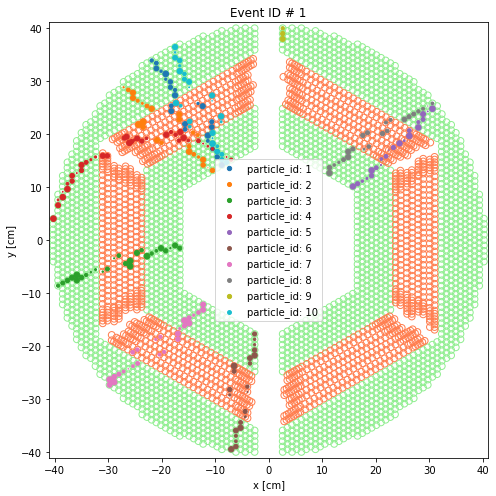

In [25]:
Draw_Reader_Event(reader(1),figsize=(7,7),save_fig=False);

In [26]:
# for e in range(100):
#    data = csv_reader(e)
#    Draw_Reader_Event(data,figsize=(10, 10),save_fig=True);

### _(A) - Event Class_

- See how to effectivly use this class.

In [27]:
from src import Event

In [28]:
# TODO: Make it working?
event = Event(input_dir=input_dir, noise=True, skewed=True)

In [29]:
# let's read an event
evtid = 1
event.read(evtid)

True

In [30]:
if not event.read(evtid):
    print("event {} does not have truth info".format(evtid))
else:
    print("event {} does have truth info".format(evtid))

event 1 does have truth info


In [31]:
event.reconstructable_pids()

array([ 1,  2,  3,  4,  5,  6,  7,  8, 10])